Simulating BER:  17%|█▋        | 1/6 [35:20<2:56:41, 2120.40s/it]

Eb/N0=5 dB, BER=7.19000e-04


Simulating BER:  33%|███▎      | 2/6 [59:34<1:55:13, 1728.47s/it]

Eb/N0=6 dB, BER=4.50000e-05


Simulating BER:  50%|█████     | 3/6 [1:21:58<1:17:38, 1552.81s/it]

...

Eb/N0=8 dB, BER=0.00000e+00


Simulating BER:  83%|████████▎ | 5/6 [2:06:27<23:38, 1418.91s/it]

Eb/N0=9 dB, BER=0.00000e+00


Simulating BER: 100%|██████████| 6/6 [2:28:42<00:00, 1487.12s/it]

Eb/N0=10 dB, BER=0.00000e+00


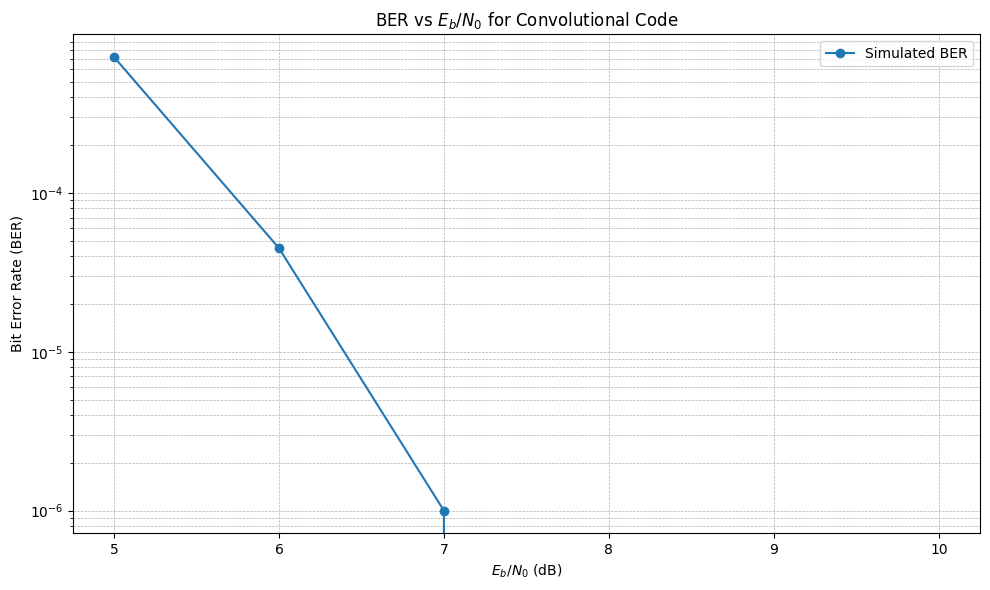

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from commpy.channelcoding import Trellis, conv_encode, viterbi_decode
from commpy.modulation import PSKModem
from tqdm import tqdm  # Optional: For progress bar

def simulate_ber(EbN0_dB_list, num_bits_per_EbN0):
    # Convolutional code parameters
    constraint_length = 7
    generator_polynomials = np.array([0o171, 0o133])  # Octal representation
    code_rate = 1/2
    trellis = Trellis(memory=np.array([constraint_length - 1]),
                      g_matrix=generator_polynomials.reshape(1, -1))

    # Modulation parameters
    modem = PSKModem(2)  # BPSK
    bits_per_symbol = int(np.log2(modem.m))

    # BER results storage
    ber = []

    # Iterate over each Eb/N0 value
    for EbN0_dB in tqdm(EbN0_dB_list, desc='Simulating BER'):
        # Initialize error counters
        total_bits = 0
        total_errors = 0

        # Number of bits to simulate per Eb/N0
        num_bits = num_bits_per_EbN0

        # Generate random bits
        data_bits = np.random.randint(0, 2, num_bits)

        # Convolutional Encoding
        conv_encoded_bits = conv_encode(data_bits, trellis)

        # Modulation (BPSK)
        modulated_symbols = modem.modulate(conv_encoded_bits)

        # Calculate noise variance based on Eb/N0
        EbN0_linear = 10 ** (EbN0_dB / 10)
        noise_variance = 1 / (2 * code_rate * EbN0_linear)  # Assuming Es=1

        # AWGN Channel
        noise = np.sqrt(noise_variance) * (np.random.randn(len(modulated_symbols)) + 
                                          1j * np.random.randn(len(modulated_symbols)))
        received_symbols = modulated_symbols + noise

        # Demodulation (Hard Decision)
        demodulated_bits = modem.demodulate(received_symbols, demod_type='hard')

        # Viterbi Decoding
        decoded_bits = viterbi_decode(demodulated_bits.astype(int), trellis, 
                                     tb_depth=5 * (constraint_length - 1))
        decoded_bits = decoded_bits[:len(data_bits)]  # Truncate to original length

        # Count bit errors
        bit_errors = np.sum(data_bits != decoded_bits)
        total_errors += bit_errors
        total_bits += len(data_bits)

        # Calculate BER
        ber_value = total_errors / total_bits
        ber.append(ber_value)

        # Optional: Print progress for each Eb/N0
        print(f'Eb/N0={EbN0_dB} dB, BER={ber_value:.5e}')

    return EbN0_dB_list, ber

def main():
    # Simulation parameters
    EbN0_dB_list = np.arange(5, 11, 1)  # Eb/N0 from 5 dB to 10 dB
    num_bits_per_EbN0 = 2 * 10**6      # Number of bits per Eb/N0 point

    # Simulate BER
    EbN0_dB_list, ber = simulate_ber(EbN0_dB_list, num_bits_per_EbN0)

    # Plotting the BER vs. Eb/N0
    plt.figure(figsize=(10, 6))
    plt.semilogy(EbN0_dB_list, ber, 'o-', label='Simulated BER')
    plt.title('BER vs $E_b/N_0$ for Convolutional Code')
    plt.xlabel('$E_b/N_0$ (dB)')
    plt.ylabel('Bit Error Rate (BER)')
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()
